[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch02_workbook.ipynb)

# Three models and the same ten words

A language model gives every next word a probability, and a whole sentence the
product of those probabilities. Of three models that predict the same ten
words, A puts 0.9 on the right word nine times and 0 on the tenth, B puts 0.3 on
the right word every time and 0.4 on one other word, and C puts 1/10,000 on
every word of a 10,000-word vocabulary: which model predicts the ten words
best, and what one number would settle it?

In [1]:
#@title Setup: run this cell first
import math
import os
import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


# The lecture's toy examples (decks/ch02/question.tex): the running sentence, the sentence its
# bigram estimates set to zero, the four factors of "the cat sat on", and the opening puzzle:
# A puts A_RIGHT on the right word nine times and 0 on the tenth, B puts B_RIGHT on it and
# B_OTHER on one other word, C puts 1/C_VOCAB on every word.
SENT, ZERO_SENT, FRAME_FACTORS = "the cat sat on the mat", "the cat on the mat", [0.33, 0.50, 0.80, 0.70]
A_RIGHT, A_PUZZLE, B_RIGHT, B_OTHER, C_VOCAB = 0.9, 0, 0.3, 0.4, 10000
# Q_THE is the probability on "the" of the model Q of the frame "Cross-Entropy Averages the
# Model's Cost Over Text From the Language", which shares the rest among the other words of SENT;
# P_KL and Q_KL are the two distributions of the frame "Cross-Entropy Is Entropy Plus a KL
# Divergence That Differs by Direction".
Q_THE, P_KL, Q_KL = 0.9, np.array([0.9, 0.1]), np.array([0.5, 0.5])
LENGTH = 1500  # the words of step 1's sentence, past the frame's axis at 1,250
# The training log's loss in nats a token, from the frame on a loss in nats; and from the frame
# "A Trigram's Perplexity Is ... on Its Training Text and ... on Chapter 15", the perplexities of
# the lecture's trigram on the course corpus: fitted on chapters 1 to 13 of the course's
# companions and scored on them and on chapter 15, held out.
DECK_LOSS, DECK_PPL = 3.91, (4.90, 666.85)
# The course trigram's weights on its trigram, bigram and unigram count ratios, and UNIFORM on
# 1/V (tools/measure_calibration.py).
TRIGRAM, UNIFORM = (0.55, 0.28, 0.16), 0.01


# A setting a cell refuses: Colab prints the one sentence, without the stack.
class Refused(Exception):
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


def need(ok, name, value, rule):
    if not ok:
        shown = repr(value) if len(repr(value)) <= 40 else repr(value)[:39] + "…"
        raise Refused(f"{name} is {shown}, of type {type(value).__name__}: {name} takes {rule}.")


# Step 1's sentence: its first words take the factors, every later word their geometric mean.
# Returns the factors, log₁₀ P at every length, the product of doubles (Python's floats), the first
# words before the product passes the smallest normal double, the words before it is 0.0,
# and what it does there. The product never rises, so a count of words gives each position.
def chain(factors):
    ok = isinstance(factors, list) and 1 <= len(factors) <= 20 and all(type(x) in (int, float) and 0.001 <= x <= 1 for x in factors)
    need(ok, "FACTORS", factors, "a list of 1 to 20 probabilities, each from 0.001 to 1")
    f = np.r_[factors, np.full(LENGTH - len(factors), 10 ** np.mean(np.log10(factors)))]
    logp, p = np.cumsum(np.log10(f)), np.cumprod(f)
    end, normal = int((p > 0).sum()), int((p >= np.finfo(float).tiny).sum())
    fate = f"is 0.0 from word {end + 1:,}" if end < LENGTH else "stays above 0.0"
    if end == LENGTH and p[-1] == p[-2] and f[-1] < 1:
        fate = f"reaches {p[-1]:.2g} at word {int((p > p[-1]).sum()) + 1:,} and stays there"
    return f, logp, p, normal, end, fate


def show_chain(factors):
    f, logp, p, normal, end, fate = chain(factors)
    fig, ax = plt.subplots(figsize=(6, 4.2), layout="constrained")
    ax.plot(range(1, LENGTH + 1), logp, "k-", label="sum of the log₁₀ of the factors")
    ax.plot(range(1, end + 1), np.log10(p[:end]), "o--", ms=4, markevery=end // 25 + 1, label=f"product of doubles, which {fate}")
    if normal < LENGTH:
        ax.axhline(np.log10(np.finfo(float).tiny), color="C3", ls=":", label=f"smallest normal double, passed at word {normal + 1:,}")
    ax.set(xlabel="sentence length in words", ylabel="log₁₀ of the probability")
    fig.legend(loc="outside lower center", fontsize=8)
    plt.show()


# A sentence's factors by the count ratio, (label, count, denominator) each: C(w) / N for its
# first word, then C(u w) / C(u), where C(u) counts the pairs u opens inside the corpus's
# sentences, which . ! or ? ends; and the corpus's pairs and C(u). A text holds letters, spaces and,
# in CORPUS, the marks , ; : . ! ?, so splitting it changes no word; capitals are read as lowercase.
def factors_of(corpus, sentence):
    for name, text, most, chars, said in [("CORPUS", corpus, 400, "[a-zA-Z ,;:.!?]*", ", spaces and , ; : . ! ?"),
                                          ("SENTENCE", sentence, 20, "[a-zA-Z ]*", " and spaces")]:
        ok = isinstance(text, str) and re.fullmatch(chars, text) and 1 <= len(re.findall("[a-zA-Z]+", text)) <= most
        need(ok, name, text, f"a text of 1 to {most} words, written with the letters a to z{said}")
    s, w = [re.findall("[a-z]+", x.lower()) for x in re.split("[.!?]", corpus)], sentence.lower().split()
    pairs, opens = Counter(p for y in s for p in zip(y, y[1:])), Counter(u for y in s for u in y[:-1])
    rows = [(f"P({w[0]})", sum(y.count(w[0]) for y in s), sum(map(len, s)))]
    return rows + [(f"P({b} ∣ {a})", pairs[(a, b)], opens[a]) for a, b in zip(w, w[1:])], pairs, opens


# The corpus's bigram estimates, then the sentence's factors and their running product as a table,
# the running product to two significant digits.
def show_factors(corpus, sentence):
    rows, pairs, opens = factors_of(corpus, sentence)
    print("bigram estimates:", ", ".join(f"{a} {b} {k}/{opens[a]} = {k / opens[a]:.2f}" for (a, b), k in pairs.items()))
    run = np.cumprod([k / d if d else 0.0 for _, k, d in rows])
    table = [f"| {r[0]} | {r[1]}/{r[2]} | {x:.2g} |" for r, x in zip(rows, run)]
    display(Markdown("| factor | count ratio | running product |\n| --- | ---: | ---: |\n" + "\n".join(table)))


# Bits a word over the ten words for the puzzle's models, A giving its tenth word a_tenth; at 0
# A's cost has no bound, and its bits are None.
def puzzle(a_tenth):
    need(type(a_tenth) in (int, float) and 0 <= a_tenth <= 0.1, "A_TENTH", a_tenth, "a number from 0 to 0.1")
    a = (9 * -math.log2(A_RIGHT) - math.log2(a_tenth)) / 10 if a_tenth else None
    return {"A": a, "B": -math.log2(B_RIGHT), "C": math.log2(C_VOCAB)}


# A cost with no bound is a hatched bar cut at 1.15 times the longest finite one. C's top guess is a
# 10,000-way tie, right an expected 10 times in 10,000.
def show_puzzle(a_tenth):
    v = list(puzzle(a_tenth).values())
    top, cut = 1.15 * max(x for x in v if x is not None), [x is None for x in v]
    names = ["A\ntop guess right\n9 of 10", "B\ntop guess right\n0 of 10", f"C\ntop guess right\n{10 / C_VOCAB:g} expected"]
    fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
    bars = ax.barh(names, [top if c else x for c, x in zip(cut, v)], color=["white" if c else "C0" for c in cut],
                   edgecolor="C0", hatch=["//" if c else "" for c in cut])
    ax.bar_label(bars, ["no bound, cut here" if c else f"{x:.2f}" for c, x in zip(cut, v)], fontsize=9, padding=3)
    ax.set(xlabel="bits a word", xlim=(0, 1.6 * top), ylim=(2.6, -0.6))
    plt.show()


# The interpolated model's perplexity on tokens, 2 to the mean cost in bits, with the weights
# on the trigram, bigram and unigram count ratios of the training chapters, UNIFORM on 1/V.
def perplexity(t, w3, w2, w1):
    def prob(g):
        return w3 * tri[g] / max(h3[g[:2]], 1) + w2 * bi[g[1:]] / max(h2[g[1]], 1) + w1 * uni[g[2]] / len(train)
    return 2 ** -np.mean([math.log2(prob(g) + UNIFORM / len(uni)) for g in zip(t, t[1:], t[2:])])


chapters = load_novel()
n_train = round(0.9 * len(chapters))
train, test = ([w for c in part for w in c] for part in (chapters[:n_train], chapters[n_train:]))
pad, held = ["<s>", "<s>"] + train, ["<s>", "<s>"] + test
tri, h3 = Counter(zip(pad, pad[1:], pad[2:])), Counter(zip(pad, pad[1:-1]))
bi, h2, uni = Counter(zip(pad[1:], pad[2:])), Counter(pad[1:-1]), Counter(train)
display(Markdown(f'The running sentence is "{SENT}". Pride and Prejudice has {len(chapters)} chapters: the first {n_train}, '
                 f"{len(train):,} tokens of {len(uni):,} types, fit the trigram; the last {len(test):,} tokens test it."))

The running sentence is "the cat sat on the mat". Pride and Prejudice has 61 chapters: the first 55, 110,030 tokens of 6,102 types, fit the trigram; the last 12,144 tokens test it.

## 1. One probability per sentence

The chain rule gives a sentence the product of its next-word probabilities.
In `FACTORS` the words "the cat sat on" get 0.33, 0.50, 0.80 and 0.70, and every
later word up to word 1,500 gets their geometric mean, the probability per word
that gives the same product. Run the cell, then set `FACTORS` to
`[0.2, 0.1, 0.3]`: at which word does the product, multiplied as doubles,
Python's floats, fall below the smallest normal double, where doubles start to
lose digits, and what does it do after that?

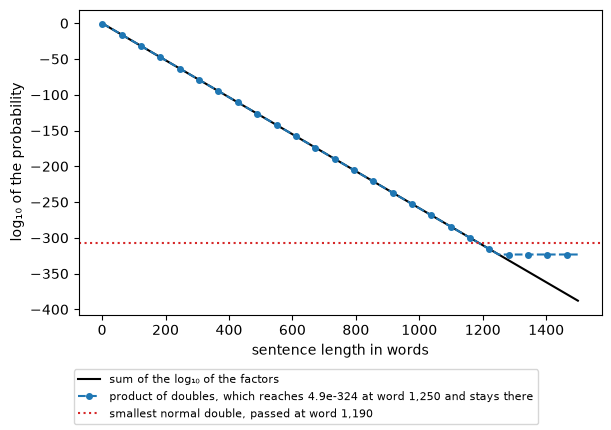

In [2]:
FACTORS = [0.33, 0.50, 0.80, 0.70]
show_chain(FACTORS)

### Solution

In [3]:
f, logp, p, normal, end, fate = chain(FACTORS)
fell = f"passes the smallest normal double at word {normal + 1:,}, at log₁₀ P {logp[normal]:.1f}, and " if normal < LENGTH else ""
display(Markdown(f"The running product of `FACTORS` ends at {np.prod(FACTORS):.3g}, and every later word gets {f[-1]:.4f}; "
                 f"after 40 words it is {p[39]:.2g}, log₁₀ P {logp[39]:.1f}. As doubles, the product {fell}{fate}. At the "
                 "default `FACTORS` the frames 'The Probability of \"the cat sat on\"' and 'Long Sentences Underflow Unless Their "
                 "Probabilities Are Added as Logarithms' print the same product, rate and crossing."))

The running product of `FACTORS` ends at 0.0924, and every later word gets 0.5513; after 40 words it is 4.5e-11, log₁₀ P -10.3. As doubles, the product passes the smallest normal double at word 1,190, at log₁₀ P -307.7, and reaches 4.9e-324 at word 1,250 and stays there. At the default `FACTORS` the frames 'The Probability of "the cat sat on"' and 'Long Sentences Underflow Unless Their Probabilities Are Added as Logarithms' print the same product, rate and crossing.

## 2. Maximum likelihood by counting

Maximum likelihood estimates the probability of a word w after a word u as the
count of the pair u w over the count of pairs that u opens, and the first word
of a sentence as its share of all words; a word that opens no pair gives the
ratio 0/0, which the count model sets to 0. Run the cell, then put a sentence of
your own into `SENTENCE`, or add a sentence to `CORPUS` after a full stop:
which factor sets the sentence's probability to zero, and what do the other
factors multiply to?

In [4]:
CORPUS = "the cat sat on the mat"
SENTENCE = "the cat on the mat"
show_factors(CORPUS, SENTENCE)

bigram estimates: the cat 1/2 = 0.50, cat sat 1/1 = 1.00, sat on 1/1 = 1.00, on the 1/1 = 1.00, the mat 1/2 = 0.50


| factor | count ratio | running product |
| --- | ---: | ---: |
| P(the) | 2/6 | 0.33 |
| P(cat ∣ the) | 1/2 | 0.17 |
| P(on ∣ cat) | 0/1 | 0 |
| P(the ∣ on) | 1/1 | 0 |
| P(mat ∣ the) | 1/2 | 0 |

### Solution

In [5]:
rows = factors_of(CORPUS, SENTENCE)[0]
zeros, kept = [r for r in rows if r[1] == 0], [r for r in rows if r[1]]
num, den = math.prod(r[1] for r in kept), math.prod(r[2] for r in kept)
rest = f"{num // math.gcd(num, den):,}/{den // math.gcd(num, den):,} = {num / den:.3g}"
said = "; ".join(f"{r[0]} is {r[1]}/{r[2]}" for r in zeros) + ": the sentence's probability is 0" if zeros else "No factor is 0"
said += f", and the product of the factors above 0 is {rest}" if kept else ""
display(Markdown(said + ". At the default CORPUS and SENTENCE the frames 'Counting \"the cat sat on the mat\" Gives Five Bigram "
                 "Estimates' and 'One Unseen Bigram Sets the Whole Sentence to Zero' print the same count ratios."))

P(on ∣ cat) is 0/1: the sentence's probability is 0, and the product of the factors above 0 is 1/12 = 0.0833. At the default CORPUS and SENTENCE the frames 'Counting "the cat sat on the mat" Gives Five Bigram Estimates' and 'One Unseen Bigram Sets the Whole Sentence to Zero' print the same count ratios.

## 3. Bits, entropy and cross-entropy

A word costs no bits when the model gave it probability 1, one bit at one half,
and one bit more for every halving. A model's mean cost on a text, in bits a
word, is its cross-entropy on the text. For a model Q that gives each word one
probability whatever precedes it, the cross-entropy on text drawn from a
distribution P is the entropy of P plus the KL divergence D(P‖Q) from P to Q.
The divergence is 0 or more, and 0 only at Q equal to P, so the entropy of P is
the lowest cross-entropy such a model reaches. `A_TENTH` is the probability
model A gives the tenth word; B and C are the opening puzzle's. Run the cell,
then set `A_TENTH` to 0.01: which model costs the fewest bits a word, and where
does A rank by bits and by right top guesses?

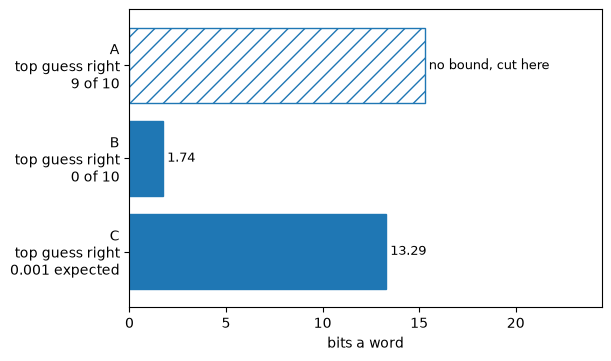

In [6]:
A_TENTH = 0
show_puzzle(A_TENTH)

### Solution

In [7]:
cost = {m: v for m, v in puzzle(A_TENTH).items() if v is not None}
rank = sorted(cost, key=cost.get)
alike = [(a, b) for a, b in zip(rank, rank[1:]) if f"{cost[a]:.2f}" == f"{cost[b]:.2f}"]
ties = "".join(f"; {a} and {b} print alike, at {cost[a]:.6f} and {cost[b]:.6f}" for a, b in alike)
P = np.array(list(Counter(SENT.split()).values())) / len(SENT.split())  # "the" first, then cat, sat, on, mat
Q = np.r_[Q_THE, np.full(len(P) - 1, (1 - Q_THE) / (len(P) - 1))]
display(Markdown("From fewest bits a word, ties in the order A, B, C: " + ", ".join(f"{m} at {cost[m]:.2f}" for m in rank)
                 + ("" if "A" in cost else ", then A: it gave the tenth word probability 0, so its cost has no bound") + ties
                 + f". By right top guesses A ranks first, 9 of 10, and the frame 'Three Models, Scored by Right Answers and by "
                 f"Bits' prints B's {cost['B']:.2f} and C's {cost['C']:.2f}. On '{SENT}' the entropy is {-P @ np.log2(P):.4f} bits, "
                 f"the model with {Q_THE:.2f} on 'the' has the cross-entropy {-P @ np.log2(Q):.4f}, and for P {tuple(P_KL.tolist())} "
                 f"and Q {tuple(Q_KL.tolist())} D(P‖Q) is {P_KL @ np.log2(P_KL / Q_KL):.4f} and D(Q‖P) "
                 f"{Q_KL @ np.log2(Q_KL / P_KL):.4f}, as the frames on entropy, cross-entropy and the KL divergence print."))

From fewest bits a word, ties in the order A, B, C: B at 1.74, C at 13.29, then A: it gave the tenth word probability 0, so its cost has no bound. By right top guesses A ranks first, 9 of 10, and the frame 'Three Models, Scored by Right Answers and by Bits' prints B's 1.74 and C's 13.29. On 'the cat sat on the mat' the entropy is 2.2516 bits, the model with 0.90 on 'the' has the cross-entropy 3.5986, and for P (0.9, 0.1) and Q (0.5, 0.5) D(P‖Q) is 0.5310 and D(Q‖P) 0.7370, as the frames on entropy, cross-entropy and the KL divergence print.

## Appendix. Perplexity and its comparisons

A model's cross-entropy on N tokens w₁ … w_N is the mean cost in bits a token,

H = −(1/N) · Σ log₂ P(wᵢ | the words before wᵢ),

and its perplexity is two to that power, PP = 2^H: the number of equally likely
words a uniform choice would pick among at the same cost. Training code takes
natural logarithms, so a loss L in nats a token is L / ln 2 bits and PP = e^L;
the frame on a loss in nats reads a training log of 3.91.

A perplexity compares with another only on one held-out text under one
tokeniser. The lecture's trigram is fitted on chapters of the course corpus and
scored on them and on a held-out chapter. A trigram with its fixed weights,
0.55, 0.28, 0.16 and 0.01 on the trigram, bigram, unigram and uniform
estimates, is fitted on the first nine tenths of the chapters of Pride and
Prejudice and scored on those chapters and on the rest.

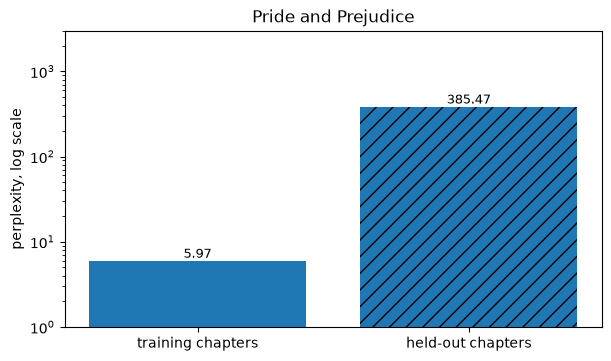

A loss of 3.91 nats a token: 5.64 bits, perplexity 49.9
Trigram on training and held-out text: Pride and Prejudice 5.97 and 385.47; course corpus, chapters 1-13 and 15, 4.90 and 666.85


In [8]:
pp = [perplexity(s, *TRIGRAM) for s in (pad, held)]
fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
bars = ax.bar(["training chapters", "held-out chapters"], pp, hatch=["", "//"])
ax.bar_label(bars, [f"{x:,.2f}" for x in pp], fontsize=9)
ax.set(yscale="log", ylim=(1, 3000), ylabel="perplexity, log scale", title="Pride and Prejudice")
plt.show()
print(f"A loss of {DECK_LOSS} nats a token: {DECK_LOSS / math.log(2):.2f} bits, "
      f"perplexity {math.exp(DECK_LOSS):.1f}")
print(f"Trigram on training and held-out text: Pride and Prejudice {pp[0]:.2f} and "
      f"{pp[1]:.2f}; course corpus, chapters 1-13 and 15, {DECK_PPL[0]:.2f} and {DECK_PPL[1]:.2f}")

**Exercise.** A gradient step moves a parameter against its gradient,
w ← w − η · dL/dw. On the loss L(w) = w², whose gradient is 2w, one step
multiplies w by 1 − 2η. Set `ETA` to 0.2, 0.8 and 1.2 in turn and rerun the
cell, which starts at w = 1: by what factor does each step multiply the loss,
and past which learning rate does each step increase it?

In [9]:
ETA = 0.2

need(type(ETA) in (int, float) and 0 <= ETA <= 10, "ETA", ETA, "a number from 0 to 10")
print("loss after 0, 1, 2 steps:", ", ".join(f"{(1 - 2 * ETA) ** (2 * k):.3g}" for k in range(3)))

loss after 0, 1, 2 steps: 1, 0.36, 0.13


### Solution

In [10]:
need(type(ETA) in (int, float) and 0 <= ETA <= 10, "ETA", ETA, "a number from 0 to 10")
b = puzzle(A_PUZZLE)
display(Markdown(f"Each step multiplies the loss by (1 − 2η)², {(1 - 2 * 0.2) ** 2:.2f} at η 0.2 and at 0.8, as the frame 'A "
                 "Learning Rate Past a Threshold Makes Each Step Increase the Loss' prints; past η 1 each step increases the "
                 f"loss, by a factor of {(1 - 2 * 1.2) ** 2:.2f} at 1.2.\n\nThe puzzle's one number is the cross-entropy: B is "
                 f"first at {b['B']:.2f} bits a word against {b['C']:.2f} for C, as the frame 'A Model's Probabilities Come "
                 "From Counts or Gradients and Are Scored in Bits' gives it, and A, right 9 times in 10, gave the tenth word "
                 "probability 0, so its cost has no bound."))

Each step multiplies the loss by (1 − 2η)², 0.36 at η 0.2 and at 0.8, as the frame 'A Learning Rate Past a Threshold Makes Each Step Increase the Loss' prints; past η 1 each step increases the loss, by a factor of 1.96 at 1.2.

The puzzle's one number is the cross-entropy: B is first at 1.74 bits a word against 13.29 for C, as the frame 'A Model's Probabilities Come From Counts or Gradients and Are Scored in Bits' gives it, and A, right 9 times in 10, gave the tenth word probability 0, so its cost has no bound.